# 导包

In [1]:
import cv2
import numpy as np
import shutil
from pathlib import Path
from scipy import ndimage
from skimage import color, exposure, measure, morphology
from matplotlib import pyplot as plt
from tiatoolbox.wsicore.wsireader import WSIReader
from tiatoolbox.models.engine.semantic_segmentor import SemanticSegmentor
from tiatoolbox.tools.registration.wsi_registration import (
    AffineWSITransformer,
    DFBRegister,
    apply_affine_transformation,
    apply_bspline_transform,
    estimate_bspline_transform,
    match_histograms,
)

|2026-01-21|16:55:52.742| [WARNING] /home/lzl/.conda/envs/tiatoolbox/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm

|2026-01-21|16:55:59.106| [WARNING] /home/lzl/.conda/envs/tiatoolbox/lib/python3.10/site-packages/albumentations/__init__.py:24: UserWarning: A new version of Albumentations is available: 2.0.8 (you have 1.4.21). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()



# 辅助函数

In [2]:
def preprocess_image(image: np.ndarray) -> np.ndarray:
    # 将RGB图像转换为灰度图像
    image = color.rgb2gray(image)

    # 对比度增强:
    # - 计算图像第0.5和99.5百分位数的像素值
    # - 将这个范围线性拉伸到[0,1],裁剪极端值,提高主要内容的对比度
    image = exposure.rescale_intensity(
        image,
        in_range=tuple(np.percentile(image, (0.5, 99.5))),
    )

    # 将归一化的[0,1]浮点值缩放到[0,255]的8位整数范围
    image = image * 255
    return image.astype(np.uint8)

In [3]:
def post_processing_mask(mask: np.ndarray) -> np.ndarray:
    """对二值掩码进行清理，只保留最大的连通区域"""
    # 填充掩码中的小孔洞
    mask = ndimage.binary_fill_holes(mask, structure=np.ones((3, 3))).astype(int)

    # 定义期望的标签数
    # 背景(0) + 前景(1) = 2个标签
    num_unique_labels = 2

    # 对二值掩码进行连通区域标记
    # 背景(0) + N个对象，共N+1个唯一标签
    label_img = measure.label(mask)
    
    if len(np.unique(label_img)) > num_unique_labels:
        regions = measure.regionprops(label_img)

        mask = mask.astype(bool)
        all_area = [i.area for i in regions]
        second_max = max([i for i in all_area if i != max(all_area)])

        # 移除所有面积 < second_max+1 的区域
        # 结果:只保留最大的连通区域
        mask = morphology.remove_small_objects(mask, min_size=second_max+1)

    return mask.astype(np.uint8)

In [4]:
def print_wsi_metadata(reader, name="WSI"):
    """打印WSI的完整元数据信息"""
    info = reader.info
    
    print(f"\n{'='*50}")
    print(f"{name} 元数据信息")
    print(f"{'='*50}")
    print(f"文件路径: {info.file_path}")
    print(f"切片尺寸 (W×H): {info.slide_dimensions[0]} × {info.slide_dimensions[1]}")
    print(f"MPP (微米/像素): {info.mpp}")
    print(f"物镜倍率: {info.objective_power}×")
    print(f"\n金字塔层级信息:")
    print(f"  层级数量: {info.level_count}")
    for i, (dims, downsample) in enumerate(zip(info.level_dimensions, 
                                                 info.level_downsamples)):
        print(f"  Level {i}: {dims[0]}×{dims[1]}, 下采样: {downsample:.2f}×")

# 数据配置

In [5]:
registration_level = 2

he_path = "/data/med/MMR/MMR-HCMI-HE-SVS/F2025-00089.svs"
ihc_path = "/backup/lzl/data/MMR/IHC/2025-03-05_15_04_40.svs"

output_dir = Path("../../test/simpleitk")
output_dir.mkdir(exist_ok=True)

he_img_gray_path = output_dir / "HE_level2_gray.png"
ihc_img_gray_path = output_dir / "IHC_level2_gray.png"
he_img_gray_match_path = output_dir / "HE_level2_gray_match.png"
ihc_img_gray_match_path = output_dir / "IHC_level2_gray_match.png"

segment_dir = output_dir / "segment"

# 图像预览

In [6]:
he_reader = WSIReader.open(he_path)
ihc_reader = WSIReader.open(ihc_path)

print_wsi_metadata(he_reader, "H&E")
print_wsi_metadata(ihc_reader, "IHC")


H&E 元数据信息
文件路径: /data/med/MMR/MMR-HCMI-HE-SVS/F2025-00089.svs
切片尺寸 (W×H): 38054 × 41152
MPP (微米/像素): [0.483101 0.483101]
物镜倍率: 20.0×

金字塔层级信息:
  层级数量: 7
  Level 0: 38054×41152, 下采样: 1.00×
  Level 1: 9513×10288, 下采样: 4.00×
  Level 2: 2378×2572, 下采样: 16.00×
  Level 3: 594×643, 下采样: 64.03×
  Level 4: 148×160, 下采样: 257.16×
  Level 5: 37×40, 下采样: 1028.64×
  Level 6: 9×10, 下采样: 4171.71×

IHC 元数据信息
文件路径: /backup/lzl/data/MMR/IHC/2025-03-05_15_04_40.svs
切片尺寸 (W×H): 68060 × 33090
MPP (微米/像素): [0.483101 0.483101]
物镜倍率: 20.0×

金字塔层级信息:
  层级数量: 7
  Level 0: 68060×33090, 下采样: 1.00×
  Level 1: 17015×8272, 下采样: 4.00×
  Level 2: 4253×2068, 下采样: 16.00×
  Level 3: 1063×517, 下采样: 64.02×
  Level 4: 265×129, 下采样: 256.67×
  Level 5: 66×32, 下采样: 1032.64×
  Level 6: 16×8, 下采样: 4195.00×


In [7]:
# 返回 numpy 数组，包含图像的像素数据
he_img_level2 = he_reader.read_region(
    location=(0, 0),
    size=he_reader.info.level_dimensions[registration_level],
    level=registration_level,
)
print("H&E 层级2 图像尺寸:", he_img_level2.shape)

H&E 层级2 图像尺寸: (2572, 2378, 3)


In [8]:
ihc_img_level2 = ihc_reader.read_region(
    location=(0, 0),
    size=ihc_reader.info.level_dimensions[registration_level],
    level=registration_level,
)
print("IHC 层级2 图像尺寸:", ihc_img_level2.shape)

IHC 层级2 图像尺寸: (2068, 4253, 3)


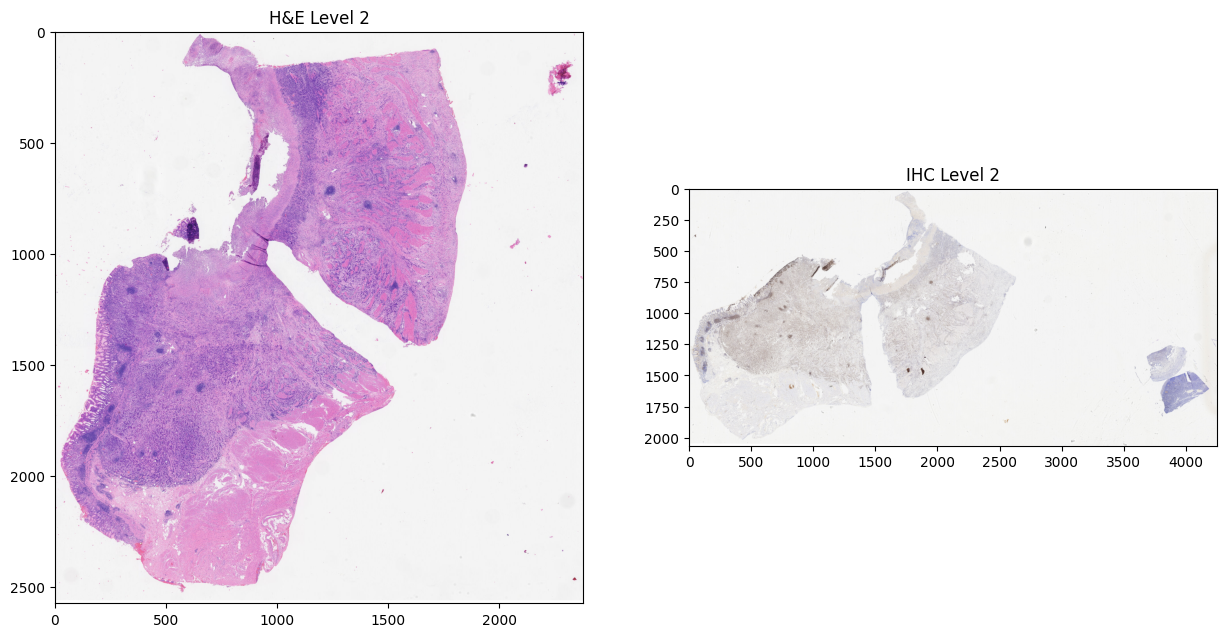

In [9]:
_, axs = plt.subplots(1, 2, figsize=(15, 10))
axs[0].imshow(he_img_level2)
axs[0].set_title("H&E Level 2")
axs[1].imshow(ihc_img_level2)
axs[1].set_title("IHC Level 2")
plt.show()

# 将RGB图像转换为灰度图像

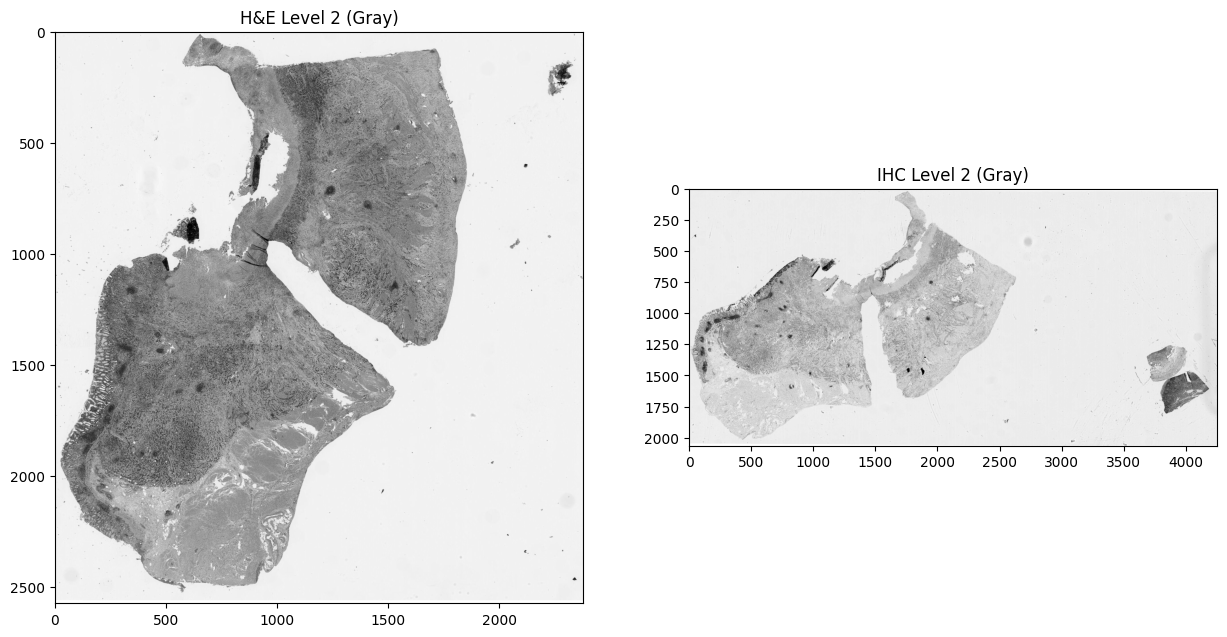

In [10]:
# 单通道灰度图像
he_img_gray_single = preprocess_image(he_img_level2)
ihc_img_gray_single = preprocess_image(ihc_img_level2)
he_img_gray = np.repeat(np.expand_dims(he_img_gray_single, axis=2), 3, axis=2)
ihc_img_gray = np.repeat(np.expand_dims(ihc_img_gray_single, axis=2), 3, axis=2)

cv2.imwrite(str(he_img_gray_path), he_img_gray)
cv2.imwrite(str(ihc_img_gray_path), ihc_img_gray)

_, axs = plt.subplots(1, 2, figsize=(15, 10))
axs[0].imshow(he_img_gray_single, cmap="gray")
axs[0].set_title("H&E Level 2 (Gray)")
axs[1].imshow(ihc_img_gray_single, cmap="gray")
axs[1].set_title("IHC Level 2 (Gray)")
plt.show()

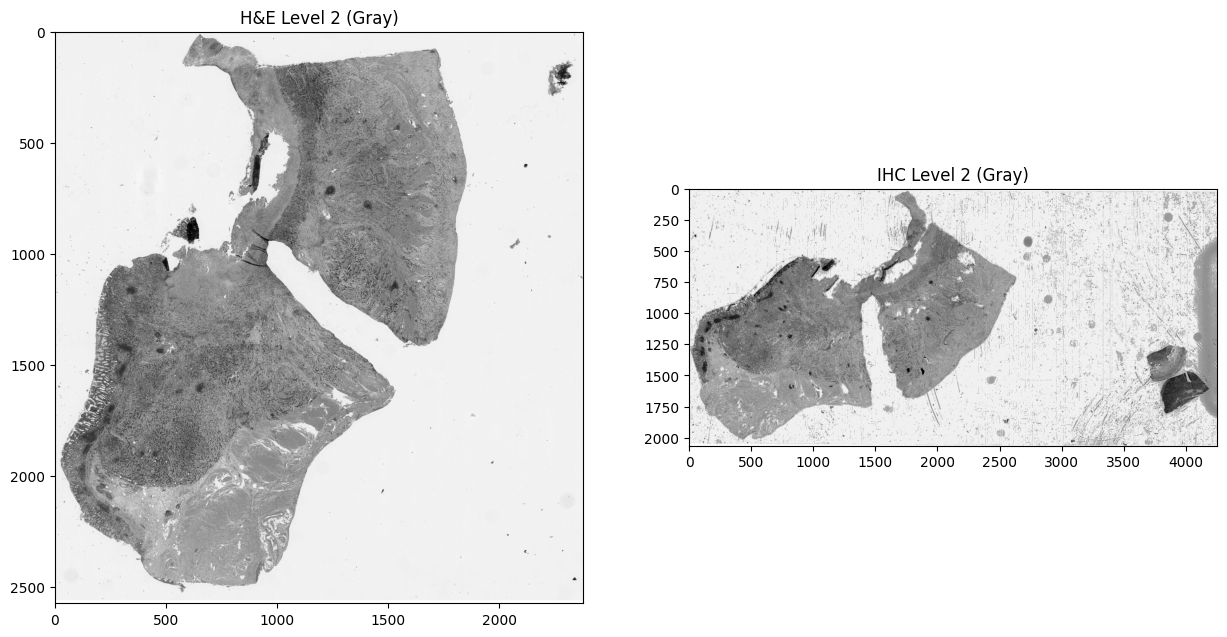

In [11]:
# 可选：直方图匹配，但不要用于组织分割，分布变化会导致错误的匹配
# 使IHC图像的亮度分布与H&E图像一致
he_img_gray_single_match, ihc_img_gray_single_match = match_histograms(
    he_img_gray_single, 
    ihc_img_gray_single
)
he_img_gray_match = np.repeat(np.expand_dims(he_img_gray_single_match, axis=2), 3, axis=2)
ihc_img_gray_match = np.repeat(np.expand_dims(ihc_img_gray_single_match, axis=2), 3, axis=2)

cv2.imwrite(str(he_img_gray_match_path), he_img_gray_match)
cv2.imwrite(str(ihc_img_gray_match_path), ihc_img_gray_match)

_, axs = plt.subplots(1, 2, figsize=(15, 10))
axs[0].imshow(he_img_gray_single_match, cmap="gray")
axs[0].set_title("H&E Level 2 (Gray)")
axs[1].imshow(ihc_img_gray_single_match, cmap="gray")
axs[1].set_title("IHC Level 2 (Gray)")
plt.show()

# 组织分割

In [12]:
segmentor = SemanticSegmentor(
    pretrained_model="unet_tissue_mask_tsef",
    num_loader_workers=4,
    batch_size=4,
)

if segment_dir.exists() and segment_dir.is_dir():
    try:
        # rmtree 可删除非空目录（包含所有子文件/子目录），rmdir() 仅能删除空目录
        shutil.rmtree(segment_dir)
        print(f"目录 {segment_dir} 已成功删除")
    except Exception as e:
        print(f"删除目录 {segment_dir} 时出错: {e}")
else:
    print(f"目录 {segment_dir} 不存在，无需删除")

|2026-01-21|16:56:15.969| [WARNING] /home/lzl/.conda/envs/tiatoolbox/lib/python3.10/site-packages/tiatoolbox/models/architecture/__init__.py:149: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this exper

目录 ../../test/simpleitk/segment 已成功删除


In [13]:
# 对存储的灰度图像进行组织分割
# 灰度图像是level 2的存储结果
# resolution=1.0, units="baseline" 表示以PNG的原始尺寸进行处理
segment_result = segmentor.predict(
    [
        str(he_img_gray_path),
        str(ihc_img_gray_path),
    ],
    save_dir=segment_dir,
    mode="tile",
    resolution=1.0,
    units="baseline",
    patch_input_shape=[1024, 1024],
    patch_output_shape=[512, 512],
    stride_shape=[512, 512],
    device="cuda",
    crash_on_exception=True,
)

|2026-01-21|16:56:17.464| [WARNING] WSIPatchDataset only reads image tile at `units="baseline"`. Resolutions will be converted to baseline value.
|2026-01-21|16:56:17.759| [WARNING] WSIPatchDataset only reads image tile at `units="baseline"`. Resolutions will be converted to baseline value.
|2026-01-21|16:56:17.929| [WARNING] Raw data is None.
|2026-01-21|16:56:17.930| [WARNING] Unknown scale (no objective_power or mpp)
Process Batch:   0%|                                      | 0/8 [00:00<?, ?it/s]|2026-01-21|16:56:18.399| [WARNING] Raw data is None.
|2026-01-21|16:56:18.400| [WARNING] Raw data is None.
|2026-01-21|16:56:18.416| [WARNING] Raw data is None.
|2026-01-21|16:56:18.416| [WARNING] Raw data is None.
Process Batch: 100%|##############################| 8/8 [00:04<00:00,  1.74it/s]

|2026-01-21|16:56:22.539| [INFO] Finish: 0
|2026-01-21|16:56:22.540| [INFO] --Input: ../../test/simpleitk/HE_level2_gray.png
|2026-01-21|16:56:22.541| [INFO] --Output: /home/lzl/code/baseline/DeeperHistReg/test/simpleitk/segment/0



|2026-01-21|16:56:22.649| [WARNING] Raw data is None.
|2026-01-21|16:56:22.650| [WARNING] Unknown scale (no objective_power or mpp)
Process Batch:   0%|                                     | 0/12 [00:00<?, ?it/s]|2026-01-21|16:56:22.807| [WARNING] Raw data is None.
|2026-01-21|16:56:22.808| [WARNING] Raw data is None.
|2026-01-21|16:56:22.808| [WARNING] Raw data is None.
|2026-01-21|16:56:22.808| [WARNING] Raw data is None.
Process Batch: 100%|############################| 12/12 [00:02<00:00,  5.41it/s]

|2026-01-21|16:56:24.877| [INFO] Finish: 0
|2026-01-21|16:56:24.877| [INFO] --Input: ../../test/simpleitk/IHC_level2_gray.png
|2026-01-21|16:56:24.877| [INFO] --Output: /home/lzl/code/baseline/DeeperHistReg/test/simpleitk/segment/1


In [14]:
# 加载Level 2的组织分割结果
# Shape: (H, W, 3) - 3个类别的概率图
# 类别0: 背景（玻片白色区域）
# 类别1: 边界/不确定区域
# 类别2: 组织（染色区域）
he_mask = np.load(segment_result[0][1] + ".raw.0.npy")
ihc_mask = np.load(segment_result[1][1] + ".raw.0.npy")

print("="*50)
print("组织分割原始输出形状")
print("="*50)

print("H&E 组织分割原始输出形状:", he_mask.shape)
print("IHC 组织分割原始输出形状:", ihc_mask.shape)

组织分割原始输出形状
H&E 组织分割原始输出形状: (2572, 2378, 3)
IHC 组织分割原始输出形状: (2068, 4253, 3)


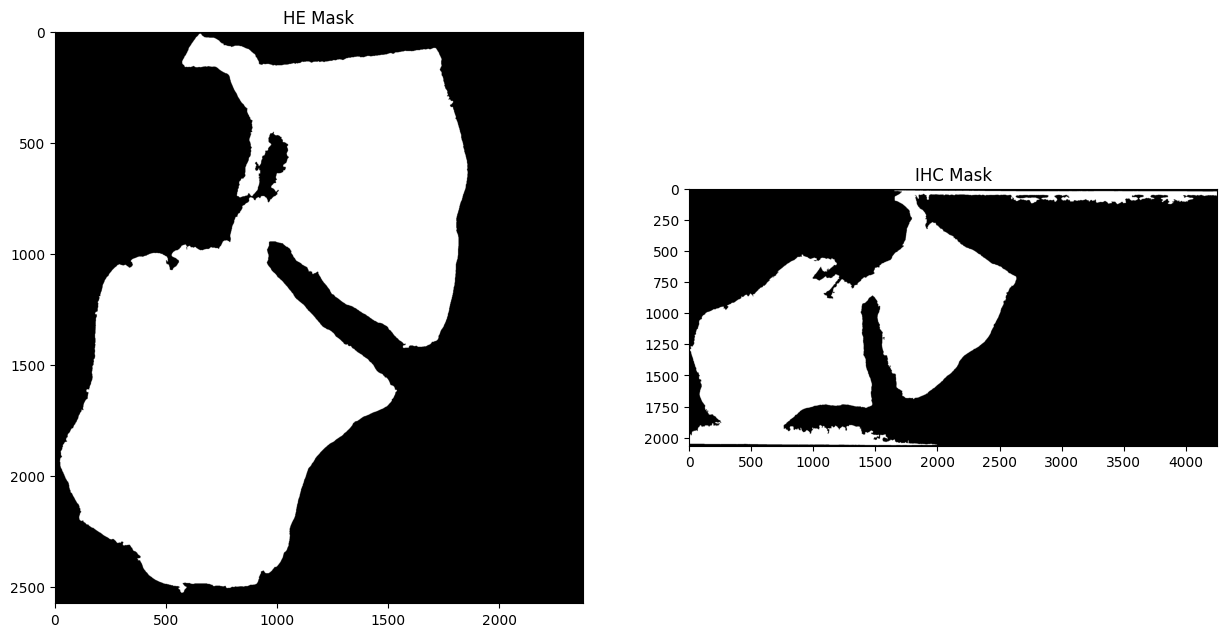

In [15]:
TISSUE_CLASS_INDEX = 2

# 从概率图转换为二值mask
he_mask = np.argmax(he_mask, axis=-1) == TISSUE_CLASS_INDEX
ihc_mask = np.argmax(ihc_mask, axis=-1) == TISSUE_CLASS_INDEX

# 对二值掩码进行清理，只保留最大的连通区域
he_mask = post_processing_mask(he_mask)
ihc_mask = post_processing_mask(ihc_mask)

_, axs = plt.subplots(1, 2, figsize=(15, 10))
axs[0].imshow(he_mask, cmap="gray")
axs[0].set_title("HE Mask")
axs[1].imshow(ihc_mask, cmap="gray")
axs[1].set_title("IHC Mask")
plt.show()

# 使用 DFBR 进行粗配准

In [16]:
dfbr = DFBRegister()

# 返回值是一个 3x3 的仿射变换矩阵
# [[a, b, tx],
# [c, d, ty],
# [0, 0, 1 ]]
# a, b, c, d: 控制旋转、缩放、剪切
# tx, ty: 控制平移
dfbr_transformer = dfbr.register(
    fixed_img=he_img_gray,
    moving_img=ihc_img_gray,
    fixed_mask=he_mask,
    moving_mask=ihc_mask,
)

|2026-01-21|16:56:31.443| [WARNING] GPU is not compatible with torch.compile. Compatible GPUs include NVIDIA V100, A100, and H100. Speedup numbers may be lower than expected.
|2026-01-21|16:56:33.417| [WARNING] The image mode is set to 'feature' as the input dimensions do not match with binary mask or RGB/RGBA.
|2026-01-21|16:56:33.421| [WARNING] The image mode is set to 'feature' as the input dimensions do not match with binary mask or RGB/RGBA.
|2026-01-21|16:56:36.243| [WARNING] The image mode is set to 'feature' as the input dimensions do not match with binary mask or RGB/RGBA.
|2026-01-21|16:56:36.252| [WARNING] The image mode is set to 'feature' as the input dimensions do not match with binary mask or RGB/RGBA.


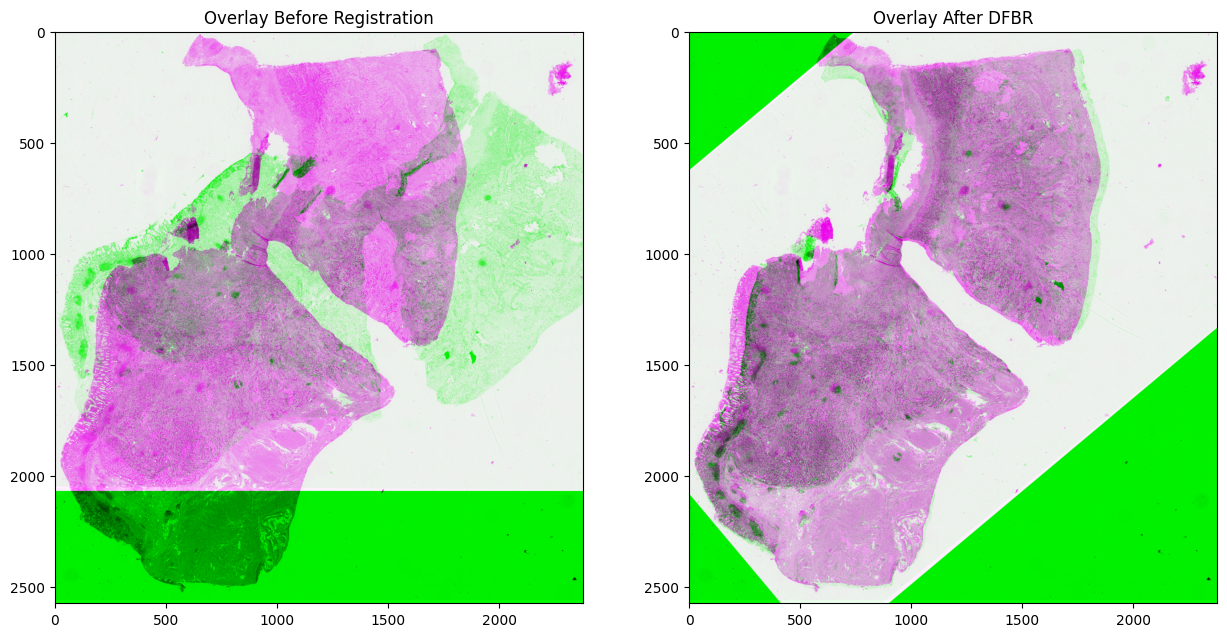

In [17]:
# 原始 IHC 图像
original_ihc = cv2.warpAffine(
    ihc_img_gray_single,
    # 创建一个 2x3 的单位仿射变换矩阵，这意味着不进行任何变换
    # 只是将 IHC 图像调整到与 HE 图像相同的尺寸
    np.eye(2, 3),
    # [::-1]将 (H, W) 转换为 (W, H)，OpenCV 要求的输入格式
    he_img_gray.shape[:2][::-1],
)
# 配准后的 IHC 图像
dfbr_registered_ihc = cv2.warpAffine(
    ihc_img_gray_single,
    dfbr_transformer[0:-1],
    he_img_gray.shape[:2][::-1],
)
# 配准后的 IHC mask
dfbr_registered_ihc_mask = cv2.warpAffine(
    ihc_mask,
    dfbr_transformer[0:-1],  # 只取前 2x3 的部分，忽略最后一行 [0, 0, 1]
    he_img_gray.shape[:2][::-1],
)

# 将配准前的移动图像、固定图像和配准前的移动图像堆叠在一起，用于可视化配准前的叠加效果
before_overlay = np.dstack((original_ihc, he_img_gray_single, original_ihc))
# 将配准后的移动图像、固定图像和配准后的移动图像堆叠在一起，用于可视化配准后的叠加效果
dfbr_overlay = np.dstack((dfbr_registered_ihc, he_img_gray_single, dfbr_registered_ihc))

_, axs = plt.subplots(1, 2, figsize=(15, 10))
axs[0].imshow(before_overlay, cmap="gray")
axs[0].set_title("Overlay Before Registration")
axs[1].imshow(dfbr_overlay, cmap="gray")
axs[1].set_title("Overlay After DFBR")
plt.show()

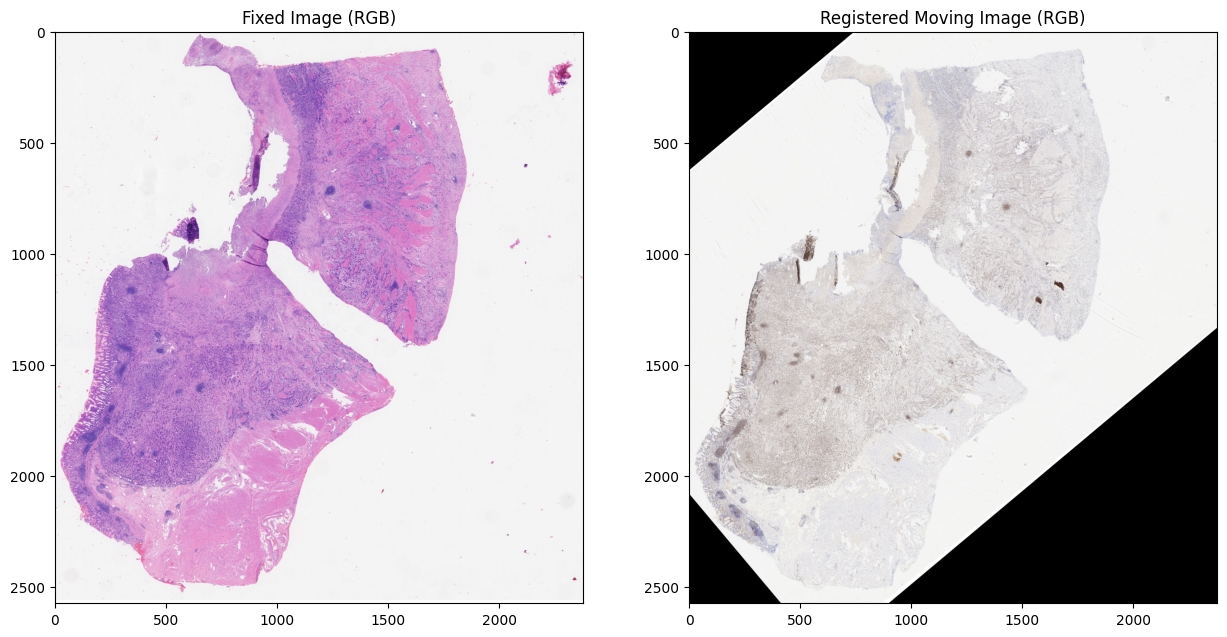

In [18]:
# 应用变换矩阵到 RGB 图像
affine_matrix = dfbr_transformer[0:-1]
dfbr_registered_ihc_img_level2 = cv2.warpAffine(
    ihc_img_level2,
    affine_matrix,
    (he_img_level2.shape[1], he_img_level2.shape[0]),  # (width, height)
    flags=cv2.INTER_LINEAR,  # 线性插值，在变换过程中平滑地计算新像素值
    borderMode=cv2.BORDER_CONSTANT,  # 边界处理模式：变换后超出范围的区域用常量填充
    borderValue=(0, 0, 0)  # 填充值为黑色
)

_, axs = plt.subplots(1, 2, figsize=(15, 10))
axs[0].imshow(he_img_level2)
axs[0].set_title("Fixed Image (RGB)")
axs[1].imshow(dfbr_registered_ihc_img_level2)
axs[1].set_title("Registered Moving Image (RGB)")
plt.show()

## Patch Level 查看

In [19]:
# 获取 level 2 相对于 level 0 的下采样倍数
downsample_factor = he_reader.info.level_downsamples[registration_level]
print(f"Level {registration_level} 下采样倍数: {downsample_factor}") 

Level 2 下采样倍数: 16.00126156433978


In [20]:
scale_matrix = np.array([
    [downsample_factor, 0, 0],
    [0, downsample_factor, 0],
    [0, 0, 1]
])

inverse_scale_matrix = np.array([
    [1/downsample_factor, 0, 0],
    [0, 1/downsample_factor, 0],
    [0, 0, 1]
])

# 变换顺序：先缩放到level 0坐标，再应用变换，最后缩放回来
# T_level0 = S * T_level2 * S^(-1)
transform_level0 = scale_matrix @ dfbr_transformer @ inverse_scale_matrix

print(f"level 2 变换矩阵: {dfbr_transformer}")
print(f"level 0 变换矩阵: {transform_level0}")

transformed_ihc = AffineWSITransformer(ihc_reader, transform_level0)

level 2 变换矩阵: [[ 7.66044443e-01  6.42787610e-01 -7.15513681e+02]
 [-6.42787610e-01  7.66044443e-01  1.22659434e+03]
 [ 0.00000000e+00  0.00000000e+00  1.00000000e+00]]
level 0 变换矩阵: [[ 7.66044443e-01  6.42787610e-01 -1.14491216e+04]
 [-6.42787610e-01  7.66044443e-01  1.96270569e+04]
 [ 0.00000000e+00  0.00000000e+00  1.00000000e+00]]


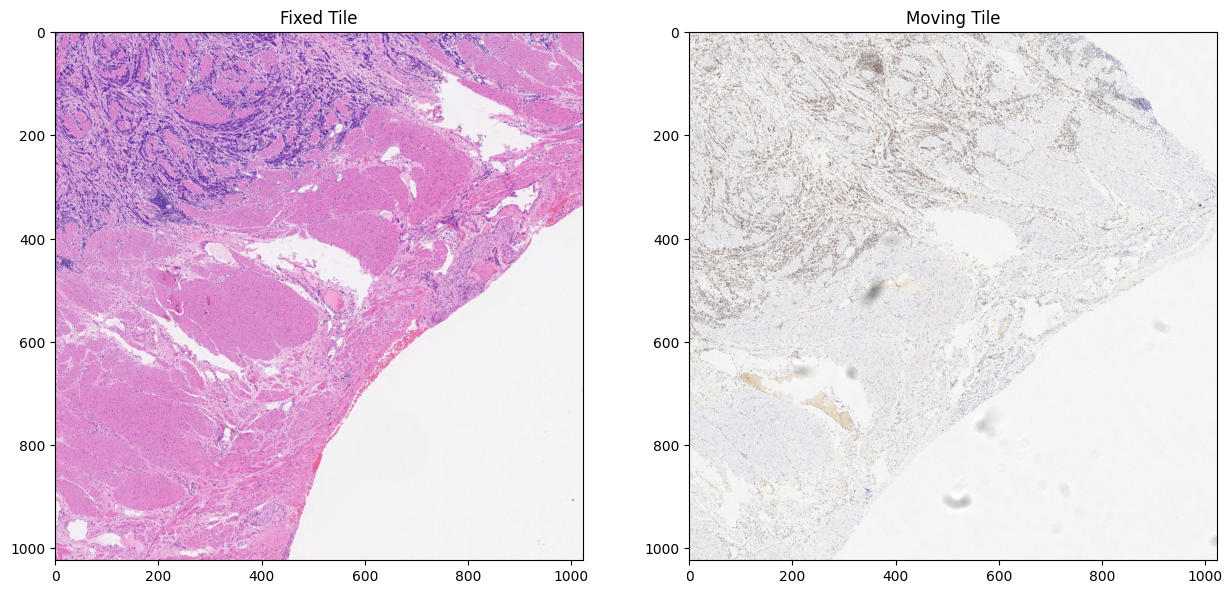

In [31]:
location = (14000, 25000)
size = (1024, 1024)

he_patch = he_reader.read_rect(location, size, resolution=2.5, units="power")
ihc_patch = transformed_ihc.read_rect(location, size, resolution=2.5, units="power")

_, axs = plt.subplots(1, 2, figsize=(15, 10))
axs[0].imshow(he_patch, cmap="gray")
axs[0].set_title("Fixed Tile")
axs[1].imshow(ihc_patch, cmap="gray")
axs[1].set_title("Moving Tile")
plt.show()

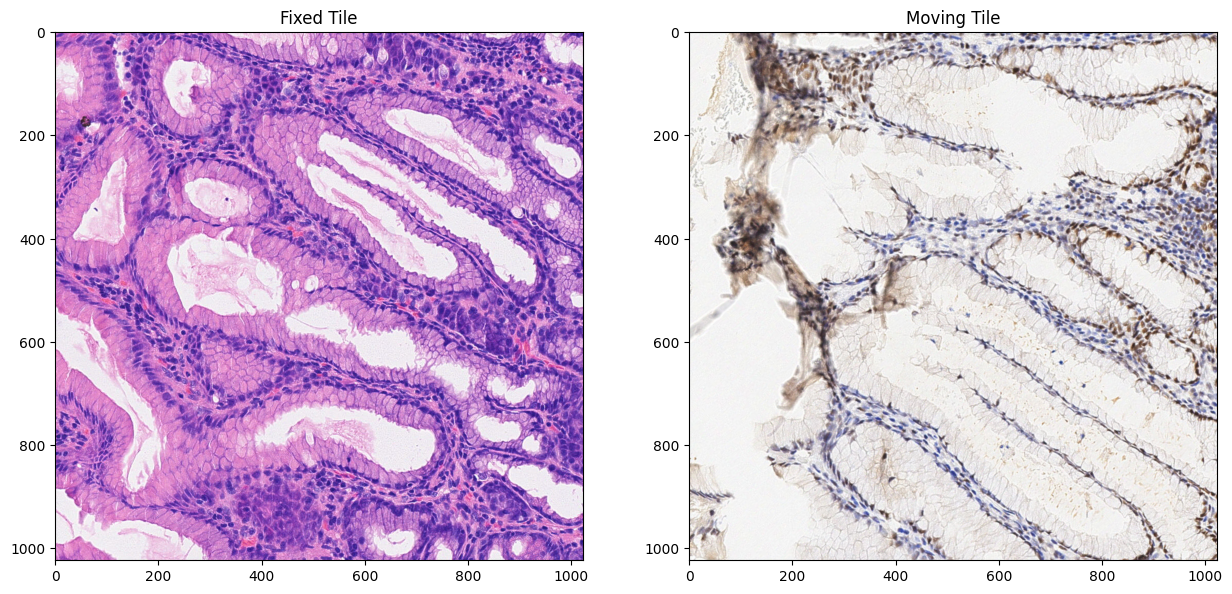

In [35]:
location = (2700, 26000)
size = (1024, 1024)

he_patch = he_reader.read_rect(location, size, resolution=0, units="level")
ihc_patch = transformed_ihc.read_rect(location, size, resolution=0, units="level")

_, axs = plt.subplots(1, 2, figsize=(15, 10))
axs[0].imshow(he_patch, cmap="gray")
axs[0].set_title("Fixed Tile")
axs[1].imshow(ihc_patch, cmap="gray")
axs[1].set_title("Moving Tile")
plt.show()

# 使用 SimpleITK 进行非刚性配准